# hlb-CIFAR10 — Notebook Colab
Script d'entraînement de haut niveau et facilement modifiable pour CIFAR-10.

In [1]:
# Clear notebook state to avoid bugs from re-running cells
try:
    _ = get_ipython().__class__.__name__
    %reset -f
except NameError:
    pass

## 1. Importations

In [2]:
import functools
from functools import partial
import os
import copy

import torch
import torch.nn.functional as F
from torch import nn

import torchvision
from torchvision import transforms

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

torch.cuda.empty_cache()

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## 2. Hyperparamètres
Il faut modifier ces valeurs avant de lancer le reste du notebook :
- `batchsize` : augmenter pour utiliser plus de VRAM (doit rester une puissance de 2 idéalement)
- `base_depth` : `64` (rapide, ~93 %) → `128` (haute précision ~95,79 %+)
- `train_epochs` : `1` pour un test rapide · `12` exécution courte · `90` pour la précision maximale
- `nb_runs` : nombre de répétitions d'entraînement complètes pour les statistiques moyenne/variance

In [3]:
# set global defaults (in this particular file) for convolutions
default_conv_kwargs = {'kernel_size': 3, 'padding': 'same', 'bias': False}

nb_runs = 1
batchsize = 512
bias_scaler = 64
# To replicate the ~95.77% accuracy in 188 seconds runs, simply change the base_depth from 64->128 and the num_epochs from 10->80
hyp = {
    'opt': {
        'bias_lr':        1.15 * 1.35 * 1. * bias_scaler/batchsize, # TODO: How we're expressing this information feels somewhat clunky, is there maybe a better way to do this? :'))))
        'non_bias_lr':    1.15 * 1.35 * 1. / batchsize,
        'bias_decay':     .85 * 4.8e-4 * batchsize/bias_scaler,
        'non_bias_decay': .85 * 4.8e-4 * batchsize,
        'scaling_factor': 1./10,
        'percent_start': .2,
    },
    'net': {
        'whitening': {
            'kernel_size': 2,
            'num_examples': 50000,
        },
        'batch_norm_momentum': .8,
        'cutout_size': 0,
        'pad_amount': 3,
        'base_depth': 64 ## This should be a factor of 8 in some way to stay tensor core friendly
    },
    'misc': {
        'ema': {
            'epochs': 2,
            'decay_base': .986,
            'every_n_steps': 2,
        },
        'train_epochs': 12,
        'device': 'cuda',
        'data_location': 'data.pt',
    }
}

scaler = 2. ## You can play with this on your own if you want, for the first beta I wanted to keep things simple (for now) and leave it out of the hyperparams dict
depths = {
    'init':   round(scaler**-1*hyp['net']['base_depth']), # 64  w/ scaler at base value
    'block1': round(scaler**1*hyp['net']['base_depth']), # 128 w/ scaler at base value
    'block2': round(scaler**2*hyp['net']['base_depth']), # 256 w/ scaler at base value
    'block3': round(scaler**3*hyp['net']['base_depth']), # 512 w/ scaler at base value
    'num_classes': 10
}

## 3. Chargeur de données (Dataloader)

### 3.1. Préparation des données

Télécharge CIFAR-10, le normalise, le convertit en FP16 et le sauvegarde dans `data.pt`. Les exécutions suivantes le chargent instantanément depuis le disque.

In [4]:
if not os.path.exists(hyp['misc']['data_location']):
        cifar10_mean, cifar10_std = [
            torch.tensor([0.4913997551666284, 0.48215855929893703, 0.4465309133731618], device=hyp['misc']['device']),
            torch.tensor([0.24703225141799082, 0.24348516474564, 0.26158783926049628],  device=hyp['misc']['device'])
        ]

        transform = transforms.Compose([
            transforms.ToTensor()])

        cifar10      = torchvision.datasets.CIFAR10('cifar10/', download=True,  train=True,  transform=transform)
        cifar10_eval = torchvision.datasets.CIFAR10('cifar10/', download=False, train=False, transform=transform)

        # use the dataloader to get a single batch of all of the dataset items at once.
        train_dataset_gpu_loader = torch.utils.data.DataLoader(cifar10, batch_size=len(cifar10), drop_last=True,
                                                  shuffle=True, num_workers=2, persistent_workers=False)
        eval_dataset_gpu_loader = torch.utils.data.DataLoader(cifar10_eval, batch_size=len(cifar10_eval), drop_last=True,
                                                  shuffle=False, num_workers=1, persistent_workers=False)

        train_dataset_gpu = {}
        eval_dataset_gpu = {}

        train_dataset_gpu['images'], train_dataset_gpu['targets'] = [item.to(device=hyp['misc']['device'], non_blocking=True) for item in next(iter(train_dataset_gpu_loader))]
        eval_dataset_gpu['images'],  eval_dataset_gpu['targets']  = [item.to(device=hyp['misc']['device'], non_blocking=True) for item in next(iter(eval_dataset_gpu_loader)) ]

        def batch_normalize_images(input_images, mean, std):
            return (input_images - mean.view(1, -1, 1, 1)) / std.view(1, -1, 1, 1)

        # preload with our mean and std
        batch_normalize_images = partial(batch_normalize_images, mean=cifar10_mean, std=cifar10_std)

        ## Batch normalize datasets, now. Wowie. We did it! We should take a break and make some tea now.
        train_dataset_gpu['images'] = batch_normalize_images(train_dataset_gpu['images'])
        eval_dataset_gpu['images']  = batch_normalize_images(eval_dataset_gpu['images'])

        data = {
            'train': train_dataset_gpu,
            'eval': eval_dataset_gpu
        }

        ## Convert dataset to FP16 now for the rest of the process....
        data['train']['images'] = data['train']['images'].half()
        data['eval']['images']  = data['eval']['images'].half()

        torch.save(data, hyp['misc']['data_location'])

else:
    ## This is effectively instantaneous, and takes us practically straight to where the dataloader-loaded dataset would be. :)
    ## So as long as you run the above loading process once, and keep the file on the disc it's specified by default in the above
    ## hyp dictionary, then we should be good. :)
    data = torch.load(hyp['misc']['data_location'])


## As you'll note above and below, one difference is that we don't count loading the raw data to GPU since it's such a variable operation, and can sort of get in the way
## of measuring other things. That said, measuring the preprocessing (outside of the padding) is still important to us.

# Canonicalize labels to class indices [N] so training/eval code works across environments.
for split in ('train', 'eval'):
    targets = data[split]['targets']
    if targets.ndim == 2:
        data[split]['targets'] = targets.argmax(dim=-1).long()
    else:
        data[split]['targets'] = targets.long()

# Pad the GPU training dataset
if hyp['net']['pad_amount'] > 0:
    ## Uncomfortable shorthand, but basically we pad evenly on all _4_ sides with the pad_amount specified in the original dictionary
    data['train']['images'] = F.pad(data['train']['images'], (hyp['net']['pad_amount'],)*4, 'reflect')

### 3.2. Visualisation des classes

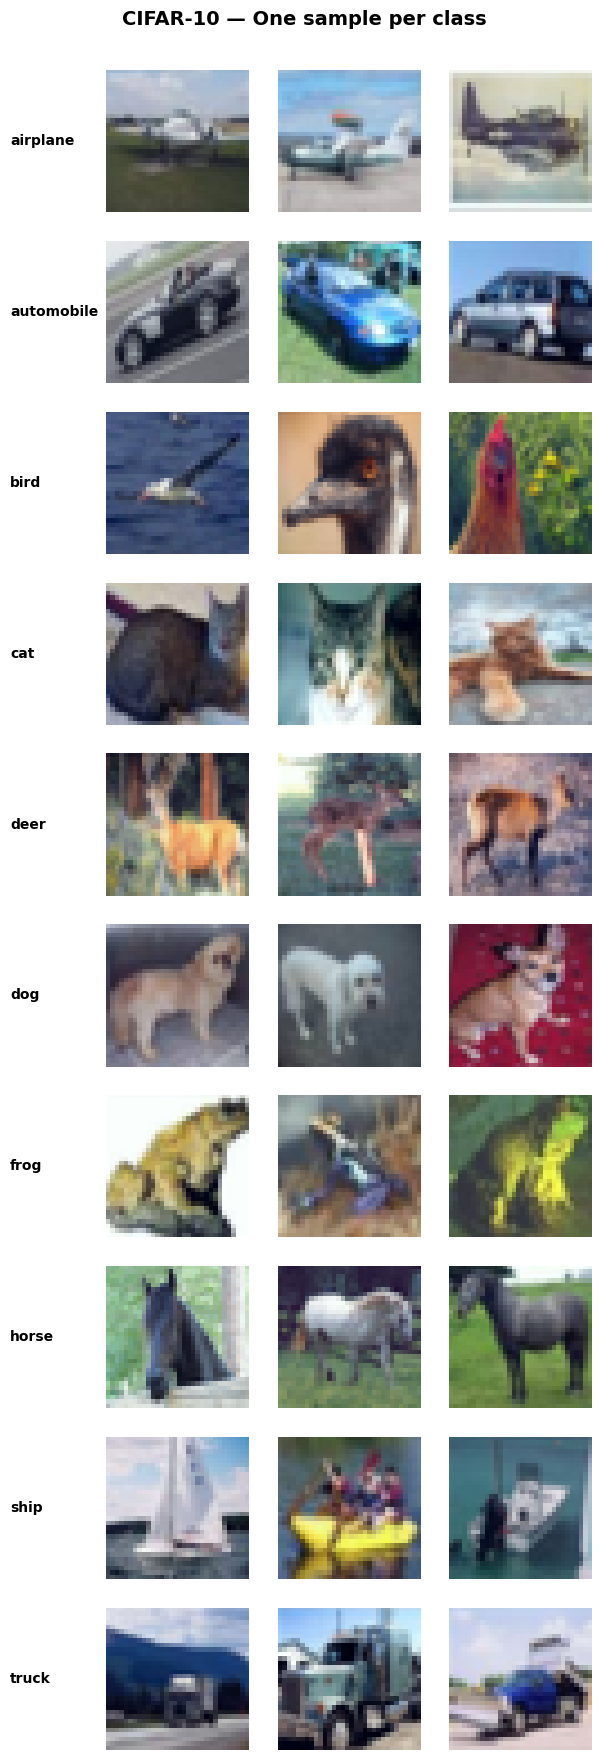

In [5]:
import matplotlib.pyplot as plt
import numpy as np

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

def show_class_samples(data_dict, classes, n_per_class=3):
    """Display n_per_class sample images for each CIFAR-10 class."""
    targets = data_dict['train']['targets']
    if targets.ndim == 2:
        labels = targets.argmax(-1).cpu()
    else:
        labels = targets.long().cpu()
    images = data_dict['train']['images'].cpu().float()

    pad = hyp['net']['pad_amount']
    if pad > 0:
        images = images[:, :, pad:-pad, pad:-pad]

    img_min = images.min()
    img_max = images.max()
    images = (images - img_min) / (img_max - img_min + 1e-8)

    n_classes  = len(classes)
    fig, axes = plt.subplots(n_classes, n_per_class,
                             figsize=(n_per_class * 2, n_classes * 2))

    fig.subplots_adjust(top=0.95, left=0.17, right=0.98)
    fig.suptitle("CIFAR-10 — One sample per class", fontsize=14, fontweight='bold')

    for class_idx, class_name in enumerate(classes):
        class_mask = (labels == class_idx).nonzero(as_tuple=True)[0]
        picks = class_mask[:n_per_class]
        for col in range(n_per_class):
            ax = axes[class_idx][col]
            if col < len(picks):
                img_idx = picks[col]
                img = images[img_idx].permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
                ax.imshow(img)
            ax.axis('off')

        row_axes  = axes[class_idx]
        bbox      = row_axes[0].get_position()          # axes coords [0,1]
        y_center  = bbox.y0 + bbox.height / 2
        fig.text(0.01, y_center, class_name,
                 fontsize=10, fontweight='bold',
                 va='center', ha='left')

    plt.show()

show_class_samples(data, CIFAR10_CLASSES, n_per_class=3)

## 4. Composants du réseau
Blocs de base : `BatchNorm`, `Conv`, `Linear`, `ConvGroup` et `FastGlobalMaxPooling`.

In [6]:
# We might be able to fuse this weight and save some memory/runtime/etc, since the fast version of the network might be able to do without somehow....
class BatchNorm(nn.BatchNorm2d):
    def __init__(self, num_features, eps=1e-12, momentum=hyp['net']['batch_norm_momentum'], weight=False, bias=True):
        super().__init__(num_features, eps=eps, momentum=momentum)
        self.weight.data.fill_(1.0)
        self.bias.data.fill_(0.0)
        self.weight.requires_grad = weight
        self.bias.requires_grad = bias

# Allows us to set default arguments for the whole convolution itself.
class Conv(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        kwargs = {**default_conv_kwargs, **kwargs}
        super().__init__(*args, **kwargs)
        self.kwargs = kwargs

# can hack any changes to each residual group that you want directly in here
class ConvGroup(nn.Module):
    def __init__(self, channels_in, channels_out, residual, short, pool, se):
        super().__init__()
        self.short = short
        self.pool = pool # todo: we can condense this later
        self.se = se

        self.residual = residual
        self.channels_in = channels_in
        self.channels_out = channels_out

        self.conv1 = Conv(channels_in, channels_out)
        self.pool1 = nn.MaxPool2d(2)
        self.norm1 = BatchNorm(channels_out)
        self.activ = nn.GELU()

        # note: this has to be flat if we're jitting things.... we just might burn a bit of extra GPU mem if so
        if not short:
            self.conv2 = Conv(channels_out, channels_out)
            self.conv3 = Conv(channels_out, channels_out)
            self.norm2 = BatchNorm(channels_out)
            self.norm3 = BatchNorm(channels_out)

            self.se1 = nn.Linear(channels_out, channels_out//16)
            self.se2 = nn.Linear(channels_out//16, channels_out)

    def forward(self, x):
        x = self.conv1(x)
        if self.pool:
            x = self.pool1(x)
        x = self.norm1(x)
        x = self.activ(x)
        if self.short: # layer 2 doesn't necessarily need the residual, so we just return it.
            return x
        residual = x
        if self.se:
            mult = torch.sigmoid(self.se2(self.activ(self.se1(torch.mean(residual, dim=(2,3)))))).unsqueeze(-1).unsqueeze(-1)
        x = self.conv2(x)
        x = self.norm2(x)
        x = self.activ(x)
        x = self.conv3(x)
        if self.se:
            x = x * mult

        x = self.norm3(x)
        x = self.activ(x)
        x = x + residual # haiku

        return x

# Set to 1 for now just to debug a few things....
class TemperatureScaler(nn.Module):
    def __init__(self, init_val):
        super().__init__()
        self.scaler = torch.tensor(init_val)

    def forward(self, x):
        x.float() ## save precision for the gradients in the backwards pass
                  ## I personally believe from experience that this is important
                  ## for a few reasons. I believe this is the main functional difference between
                  ## my implementation, and David's implementation...
        return x.mul(self.scaler)

class FastGlobalMaxPooling(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Previously was chained torch.max calls.
        # requires less time than AdaptiveMax2dPooling -- about ~.3s for the entire run, in fact (which is pretty significant! :O :D :O :O <3 <3 <3 <3)
        return torch.amax(x, dim=(2,3)) # Global maximum pooling

## 5. Définition du réseau et initialisation par blanchiment
`SpeedyConvNet` assemble l'architecture complète. `make_net` la construit et l'initialise, notamment la convolution de blanchiment fixe dans la première couche.

In [7]:
def get_patches(x, patch_shape=(3, 3), dtype=torch.float32):
    # TODO: Annotate
    c, (h, w) = x.shape[1], patch_shape
    return x.unfold(2,h,1).unfold(3,w,1).transpose(1,3).reshape(-1,c,h,w).to(dtype) # TODO: Annotate?

def get_whitening_parameters(patches):
    # TODO: Let's annotate this, please! :'D / D':
    n,c,h,w = patches.shape
    est_covariance = torch.cov(patches.view(n, c*h*w).t())
    eigenvalues, eigenvectors = torch.linalg.eigh(est_covariance, UPLO='U') # this is the same as saying we want our eigenvectors, with the specification that the matrix be an upper triangular matrix (instead of a lower-triangular matrix)
    return eigenvalues.flip(0).view(-1, 1, 1, 1), eigenvectors.t().reshape(c*h*w,c,h,w).flip(0)

# Run this over the training set to calculate the patch statistics, then set the initial convolution as a non-learnable 'whitening' layer
def init_whitening_conv(layer, train_set=None, num_examples=None, previous_block_data=None, pad_amount=None, freeze=True, whiten_splits=None):
    if train_set is not None and previous_block_data is None:
        if pad_amount > 0:
            previous_block_data = train_set[:num_examples,:,pad_amount:-pad_amount,pad_amount:-pad_amount] # if it's none, we're at the beginning of our network.
        else:
            previous_block_data = train_set[:num_examples,:,:,:]
    if whiten_splits is None:
         previous_block_data_split = [previous_block_data] # list of length 1 so we can reuse the splitting code down below
    else:
         previous_block_data_split = previous_block_data.split(whiten_splits, dim=0)

    eigenvalue_list, eigenvector_list = [], []
    for data_split in previous_block_data_split:
        eigenvalues, eigenvectors = get_whitening_parameters(get_patches(data_split, patch_shape=layer.weight.data.shape[2:])) # center crop to remove padding
        eigenvalue_list.append(eigenvalues)
        eigenvector_list.append(eigenvectors)

    eigenvalues = torch.stack(eigenvalue_list, dim=0).mean(0)
    eigenvectors = torch.stack(eigenvector_list, dim=0).mean(0)
    # for some reason, the eigenvalues and eigenvectors seem to come out all in float32 for this? ! ?! ?!?!?!? :'(((( </3
    set_whitening_conv(layer, eigenvalues.to(dtype=layer.weight.dtype), eigenvectors.to(dtype=layer.weight.dtype), freeze=freeze)
    data = layer(previous_block_data.to(dtype=layer.weight.dtype))
    return data

def set_whitening_conv(conv_layer, eigenvalues, eigenvectors, eps=1e-2, freeze=True):
    shape = conv_layer.weight.data.shape
    conv_layer.weight.data[-eigenvectors.shape[0]:, :, :, :] = (eigenvectors/torch.sqrt(eigenvalues+eps))[-shape[0]:, :, :, :]
    ## We don't want to train this, since this is implicitly whitening over the whole dataset
    ## For more info, see David Page's original blogposts (link in the README.md as of this commit.)
    if freeze:
        conv_layer.weight.requires_grad = False


class SpeedyResNet(nn.Module):
    def __init__(self, network_dict):
        super().__init__()
        self.net_dict = network_dict # flexible, defined in the make_net function

    # This allows you to customize/change the execution order of the network as needed.
    def forward(self, x):
        if not self.training:
            x = torch.cat((x, torch.flip(x, (-1,))))
        x = self.net_dict['initial_block']['whiten'](x)
        x = self.net_dict['initial_block']['project'](x)
        x = self.net_dict['initial_block']['norm'](x)
        x = self.net_dict['initial_block']['activation'](x)
        x = self.net_dict['residual1'](x)
        x = self.net_dict['residual2'](x)
        x = self.net_dict['residual3'](x)
        x = self.net_dict['pooling'](x)
        x = self.net_dict['linear'](x)
        x = self.net_dict['temperature'](x)
        if not self.training:
            # Average the predictions from the lr-flipped inputs during eval
            orig, flipped = x.split(x.shape[0]//2, dim=0)
            x = .5 * orig + .5 * flipped
        return x

def make_net():
    # TODO: A way to make this cleaner??
    # Note, you have to specify any arguments overlapping with defaults (i.e. everything but in/out depths) as kwargs so that they are properly overridden (TODO cleanup somehow?)
    whiten_conv_depth = 3*hyp['net']['whitening']['kernel_size']**2
    network_dict = nn.ModuleDict({
        'initial_block': nn.ModuleDict({
            'whiten': Conv(3, whiten_conv_depth, kernel_size=hyp['net']['whitening']['kernel_size'], padding=0),
            'project': Conv(whiten_conv_depth, depths['init'], kernel_size=1),
            'norm': BatchNorm(depths['init'], weight=False),
            'activation': nn.GELU(),
        }),
        'residual1': ConvGroup(depths['init'], depths['block1'], residual=True, short=False, pool=True, se=False),
        'residual2': ConvGroup(depths['block1'], depths['block2'], residual=True, short=True, pool=True, se=False),
        'residual3': ConvGroup(depths['block2'], depths['block3'], residual=True, short=False, pool=True, se=False),
        'pooling': FastGlobalMaxPooling(),
        'linear': nn.Linear(depths['block3'], depths['num_classes'], bias=False),
        'temperature': TemperatureScaler(hyp['opt']['scaling_factor'])
    })

    net = SpeedyResNet(network_dict)
    net = net.to(hyp['misc']['device'])
    net = net.to(memory_format=torch.channels_last) # to appropriately use tensor cores/avoid thrash while training
    net.train()
    net.half() # Convert network to half before initializing the initial whitening layer.

    ## Initialize the whitening convolution
    with torch.no_grad():
        # Initialize the first layer to be fixed weights that whiten the expected input values of the network be on the unit hypersphere. (i.e. their...average vector length is 1.?, IIRC)
        init_whitening_conv(net.net_dict['initial_block']['whiten'],
                            data['train']['images'].index_select(0, torch.randperm(data['train']['images'].shape[0], device=data['train']['images'].device)),
                            num_examples=hyp['net']['whitening']['num_examples'],
                            pad_amount=hyp['net']['pad_amount'],
                            whiten_splits=5000) ## Hardcoded for now while we figure out the optimal whitening number
                                                ## If you're running out of memory (OOM) feel free to decrease this, but
                                                ## the index lookup in the dataloader may give you some trouble depending
                                                ## upon exactly how memory-limited you are

    return net

## 6. Fonctions d'augmentation des données
Augmentations côté GPU appliquées par époque : recadrage aléatoire, retournement horizontal aléatoire.

In [8]:
## This is actually (I believe) a pretty clean implementation of how to do something like this, since shifted-square masks unique to each depth-channel can actually be rather
## tricky in practice. That said, if there's a better way, please do feel free to submit it! This can be one of the harder parts of the code to understand (though I personally get
## stuck on the fold/unfold process for the lower-level convolution calculations.
def make_random_square_masks(inputs, mask_size):
    ##### TODO: Double check that this properly covers the whole range of values. :'( :')
    if mask_size == 0:
        return None # no need to cutout or do anything like that since the patch_size is set to 0
    is_even = int(mask_size % 2 == 0)
    in_shape = inputs.shape

    # seed centers of squares to cutout boxes from, in one dimension each
    mask_center_y = torch.empty(in_shape[0], dtype=torch.long, device=inputs.device).random_(mask_size//2-is_even, in_shape[-2]-mask_size//2-is_even)
    mask_center_x = torch.empty(in_shape[0], dtype=torch.long, device=inputs.device).random_(mask_size//2-is_even, in_shape[-1]-mask_size//2-is_even)

    # measure distance, using the center as a reference point
    to_mask_y_dists = torch.arange(in_shape[-2], device=inputs.device).view(1, 1, in_shape[-2], 1) - mask_center_y.view(-1, 1, 1, 1)
    to_mask_x_dists = torch.arange(in_shape[-1], device=inputs.device).view(1, 1, 1, in_shape[-1]) - mask_center_x.view(-1, 1, 1, 1)

    to_mask_y = (to_mask_y_dists >= (-(mask_size // 2) + is_even)) * (to_mask_y_dists <= mask_size // 2)
    to_mask_x = (to_mask_x_dists >= (-(mask_size // 2) + is_even)) * (to_mask_x_dists <= mask_size // 2)

    final_mask = to_mask_y * to_mask_x ## Turn (y by 1) and (x by 1) boolean masks into (y by x) masks through multiplication. Their intersection is square, hurray! :D

    return final_mask

def batch_cutout(inputs, patch_size):
    with torch.no_grad():
        cutout_batch_mask = make_random_square_masks(inputs, patch_size)
        if cutout_batch_mask is None:
            return inputs # if the mask is None, then that's because the patch size was set to 0 and we will not be using cutout today.
        # TODO: Could be fused with the crop operation for sheer speeeeeds. :D <3 :))))
        cutout_batch = torch.where(cutout_batch_mask, torch.zeros_like(inputs), inputs)
        return cutout_batch

def batch_crop(inputs, crop_size):
    with torch.no_grad():
        crop_mask_batch = make_random_square_masks(inputs, crop_size)
        cropped_batch = torch.masked_select(inputs, crop_mask_batch).view(inputs.shape[0], inputs.shape[1], crop_size, crop_size)
        return cropped_batch

def batch_flip_lr(batch_images, flip_chance=.5):
    with torch.no_grad():
        # TODO: Is there a more elegant way to do this? :') :'(((( 
        return torch.where(torch.rand_like(batch_images[:, 0, 0, 0].view(-1, 1, 1, 1)) < flip_chance, torch.flip(batch_images, (-1,)), batch_images)

## 7. Fonctions utilitaires d'entraînement
`NetworkEMA` : moyenne mobile exponentielle des poids. `get_batches` : itérateur de mini-lots par époque avec augmentation. `init_split_parameter_dictionaries` : sépare les paramètres biais et non-biais pour des taux d'apprentissage indépendants.

In [9]:
class NetworkEMA(nn.Module):
    def __init__(self, net, decay):
        super().__init__() # init the parent module so this module is registered properly
        self.net_ema = copy.deepcopy(net).eval().requires_grad_(False) # copy the model
        self.decay = decay ## you can update/hack this as necessary for update scheduling purposes :3

    def update(self, current_net):
        with torch.no_grad():
            for ema_net_parameter, incoming_net_parameter in zip(self.net_ema.state_dict().values(), current_net.state_dict().values()): # potential bug: assumes that the network architectures don't change during training (!!!!)
                if incoming_net_parameter.dtype in (torch.half, torch.float):
                    ema_net_parameter.mul_(self.decay).add_(incoming_net_parameter.detach().mul(1. - self.decay)) # update the ema values in place, similar to how optimizer momentum is coded

    def forward(self, inputs):
        with torch.no_grad():
            return self.net_ema(inputs)

# TODO: Could we jit this in the (more distant) future? :)
@torch.no_grad()
def get_batches(data_dict, key, batchsize):
    num_epoch_examples = len(data_dict[key]['images'])
    shuffled = torch.randperm(num_epoch_examples, device='cuda')
    crop_size = 32
    ## Here, we prep the dataset by applying all data augmentations in batches ahead of time before each epoch, then we return an iterator below
    ## that iterates in chunks over with a random derangement (i.e. shuffled indices) of the individual examples. So we get perfectly-shuffled
    ## batches (which skip the last batch if it's not a full batch), but everything seems to be (and hopefully is! :D) properly shuffled. :)
    if key == 'train':
        images = batch_crop(data_dict[key]['images'], crop_size) # TODO: hardcoded image size for now?
        images = batch_flip_lr(images)
        images = batch_cutout(images, patch_size=hyp['net']['cutout_size'])
    else:
        images = data_dict[key]['images']

    # Send the images to an (in beta) channels_last to help improve tensor core occupancy (and reduce NCHW <-> NHWC thrash) during training
    images = images.to(memory_format=torch.channels_last)
    for idx in range(num_epoch_examples // batchsize):
        if not (idx+1)*batchsize > num_epoch_examples: ## Use the shuffled randperm to assemble individual items into a minibatch
            yield images.index_select(0, shuffled[idx*batchsize:(idx+1)*batchsize]), \
                  data_dict[key]['targets'].index_select(0, shuffled[idx*batchsize:(idx+1)*batchsize]) ## Each item is only used/accessed by the network once per epoch. :D


def init_split_parameter_dictionaries(network):
    params_non_bias = {'params': [], 'lr': hyp['opt']['non_bias_lr'], 'momentum': .85, 'nesterov': True, 'weight_decay': hyp['opt']['non_bias_decay']}
    params_bias     = {'params': [], 'lr': hyp['opt']['bias_lr'],     'momentum': .85, 'nesterov': True, 'weight_decay': hyp['opt']['bias_decay']}

    for name, p in network.named_parameters():
        if p.requires_grad:
            if 'bias' in name:
                params_bias['params'].append(p)
            else:
                params_non_bias['params'].append(p)
    return params_non_bias, params_bias


## Hey look, it's the soft-targets/label-smoothed loss! Native to PyTorch. Now, _that_ is pretty cool, and simplifies things a lot, to boot! :D :)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.2, reduction='none')

logging_columns_list = ['epoch', 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'ema_val_acc', 'total_time_seconds']
# define the printing function and print the column heads
def print_training_details(columns_list, separator_left='|  ', separator_right='  ', final="|", column_heads_only=False, is_final_entry=False):
    print_string = ""
    if column_heads_only:
        for column_head_name in columns_list:
            print_string += separator_left + column_head_name + separator_right
        print_string += final
        print('-'*(len(print_string))) # print the top bar
        print(print_string)
        print('-'*(len(print_string))) # print the bottom bar
    else:
        for column_value in columns_list:
            print_string += separator_left + column_value + separator_right
        print_string += final
        print(print_string)
    if is_final_entry:
        print('-'*(len(print_string))) # print the final output bar

print_training_details(logging_columns_list, column_heads_only=True) ## print out the training column heads before we print the actual content for each run.

--------------------------------------------------------------------------------------------------------
|  epoch  |  train_loss  |  val_loss  |  train_acc  |  val_acc  |  ema_val_acc  |  total_time_seconds  |
--------------------------------------------------------------------------------------------------------


## 8. Boucle d'entraînement et d'évaluation
La fonction `main()` exécute un cycle d'entraînement complet. Elle entraîne le réseau, l'évalue sur l'ensemble de test et affiche la précision finale. La boucle inclut un chronométrage par époque et une planification du taux d'apprentissage.

In [10]:
def main():
    # Initializing constants for the whole run.
    net_ema = None ## Reset any existing network emas, we want to have _something_ to check for existence so we can initialize the EMA right from where the network is during training
                   ## (as opposed to initializing the network_ema from the randomly-initialized starter network, then forcing it to play catch-up all of a sudden in the last several epochs)

    total_time_seconds = 0.
    current_steps = 0.

    # TODO: Doesn't currently account for partial epochs really (since we're not doing "real" epochs across the whole batchsize)....
    num_steps_per_epoch      = len(data['train']['images']) // batchsize
    total_train_steps        = num_steps_per_epoch * hyp['misc']['train_epochs']
    ema_epoch_start          = hyp['misc']['train_epochs'] - hyp['misc']['ema']['epochs']
    num_cooldown_before_freeze_steps = 0
    num_low_lr_steps_for_ema = hyp['misc']['ema']['epochs'] * num_steps_per_epoch

    ## I believe this wasn't logged, but the EMA update power is adjusted by being raised to the power of the number of "every n" steps
    ## to somewhat accomodate for whatever the expected information intake rate is. The tradeoff I believe, though, is that this is to some degree noisier as we
    ## are intaking fewer samples of our distribution-over-time, with a higher individual weight each. This can be good or bad depending upon what we want.
    projected_ema_decay_val  = hyp['misc']['ema']['decay_base'] ** hyp['misc']['ema']['every_n_steps']

    # Adjust pct_start based upon how many epochs we need to finetune the ema at a low lr for
    pct_start = hyp['opt']['percent_start'] * (total_train_steps/(total_train_steps - num_low_lr_steps_for_ema))

    # Get network
    net = make_net()

    ## Stowing the creation of these into a helper function to make things a bit more readable....
    non_bias_params, bias_params = init_split_parameter_dictionaries(net)

    # One optimizer for the regular network, and one for the biases. This allows us to use the superconvergence onecycle training policy for our networks....
    opt = torch.optim.SGD(**non_bias_params)
    opt_bias = torch.optim.SGD(**bias_params)

    #opt = torch.optim.SGD(**non_bias_params)
    #opt_bias = torch.optim.SGD(**bias_params)

    ## Not the most intuitive, but this basically takes us from ~0 to max_lr at the point pct_start, then down to .1 * max_lr at the end (since 1e16 * 1e-15 = .1 --
    ##   This quirk is because the final lr value is calculated from the starting lr value and not from the maximum lr value set during training)
    initial_div_factor = 1e16 # basically to make the initial lr ~0 or so :D
    final_lr_ratio = .135
    lr_sched      = torch.optim.lr_scheduler.OneCycleLR(opt,  max_lr=non_bias_params['lr'], pct_start=pct_start, div_factor=initial_div_factor, final_div_factor=1./(initial_div_factor*final_lr_ratio), total_steps=total_train_steps-num_low_lr_steps_for_ema, anneal_strategy='linear', cycle_momentum=False)
    lr_sched_bias = torch.optim.lr_scheduler.OneCycleLR(opt_bias, max_lr=bias_params['lr'], pct_start=pct_start, div_factor=initial_div_factor, final_div_factor=1./(initial_div_factor*final_lr_ratio), total_steps=total_train_steps-num_low_lr_steps_for_ema, anneal_strategy='linear', cycle_momentum=False)

    ## For accurately timing GPU code
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    ## There's another repository that's mainly reorganized David's code while still maintaining some of the functional structure, and it
    ## has a timing feature too, but there's no synchronizes so I suspect the times reported are much faster than they may be in actuality
    ## due to some of the quirks of timing GPU operations.
    torch.cuda.synchronize() ## clean up any pre-net setup operations


    if True: ## Sometimes we need a conditional/for loop here, this is placed to save the trouble of needing to indent
        for epoch in range(hyp['misc']['train_epochs']):
          #################
          # Training Mode #
          #################
          torch.cuda.synchronize()
          starter.record()
          net.train()

          loss_train = None
          accuracy_train = None

          for epoch_step, (inputs, targets) in enumerate(get_batches(data, key='train', batchsize=batchsize)):
              ## Run everything through the network
              outputs = net(inputs)

              loss_scale_scaler = 1./16 # Hardcoded for now, preserves some accuracy during the loss summing process, balancing out its regularization effects
              ## If you want to add other losses or hack around with the loss, you can do that here.
              loss = loss_fn(outputs, targets).mul(loss_scale_scaler).sum().div(loss_scale_scaler) ## Note, as noted in the original blog posts, the summing here does a kind of loss scaling
                                                     ## (and is thus batchsize dependent as a result). This can be somewhat good or bad, depending...

              # we only take the last-saved accs and losses from train
              if epoch_step % 50 == 0:
                  metric_targets = targets.argmax(-1) if targets.ndim == 2 else targets
                  train_acc = (outputs.detach().argmax(-1) == metric_targets).float().mean().item()
                  train_loss = loss.detach().cpu().item()/batchsize

              loss.backward()

              ## Step for each optimizer, in turn.
              opt.step()
              opt_bias.step()

              if current_steps < total_train_steps - num_low_lr_steps_for_ema - 1: # the '-1' is because the lr scheduler tends to overshoot (even below 0 if the final lr is ~0) on the last step for some reason.
                  # We only want to step the lr_schedulers while we have training steps to consume. Otherwise we get a not-so-friendly error from PyTorch
                  lr_sched.step()
                  lr_sched_bias.step()

              ## Using 'set_to_none' I believe is slightly faster (albeit riskier w/ funky gradient update workflows) than under the default 'set to zero' method
              opt.zero_grad(set_to_none=True)
              opt_bias.zero_grad(set_to_none=True)
              current_steps += 1

              if epoch >= ema_epoch_start and current_steps % hyp['misc']['ema']['every_n_steps'] == 0:
                  ## Initialize the ema from the network at this point in time if it does not already exist.... :D
                  if net_ema is None or epoch_step < num_cooldown_before_freeze_steps: # don't snapshot the network yet if so!
                      net_ema = NetworkEMA(net, decay=projected_ema_decay_val)
                      continue
                  net_ema.update(net)
          ender.record()
          torch.cuda.synchronize()
          total_time_seconds += 1e-3 * starter.elapsed_time(ender)

          ####################
          # Evaluation  Mode #
          ####################
          net.eval()

          eval_batchsize = 1000
          assert data['eval']['images'].shape[0] % eval_batchsize == 0, "Error: The eval batchsize must evenly divide the eval dataset (for now, we don't have drop_remainder implemented yet)."
          loss_list_val, acc_list, acc_list_ema = [], [], []

          with torch.no_grad():
              for inputs, targets in get_batches(data, key='eval', batchsize=eval_batchsize):
                  metric_targets = targets.argmax(-1) if targets.ndim == 2 else targets
                  if epoch >= ema_epoch_start:
                      outputs = net_ema(inputs)
                      acc_list_ema.append((outputs.argmax(-1) == metric_targets).float().mean())
                  outputs = net(inputs)
                  loss_list_val.append(loss_fn(outputs, targets).float().mean())
                  acc_list.append((outputs.argmax(-1) == metric_targets).float().mean())

              val_acc = torch.stack(acc_list).mean().item()
              ema_val_acc = None
              # TODO: We can fuse these two operations (just above and below) all-together like :D :))))
              if epoch >= ema_epoch_start:
                  ema_val_acc = torch.stack(acc_list_ema).mean().item()

              val_loss = torch.stack(loss_list_val).mean().item()
          # We basically need to look up local variables by name so we can have the names, so we can pad to the proper column width.
          ## Printing stuff in the terminal can get tricky and this used to use an outside library, but some of the required stuff seemed even
          ## more heinous than this, unfortunately. So we switched to the "more simple" version of this!
          format_for_table = lambda x, locals: (f"{locals[x]}".rjust(len(x))) \
                                                    if type(locals[x]) == int else "{:0.4f}".format(locals[x]).rjust(len(x)) \
                                                if locals[x] is not None \
                                                else " "*len(x)

          # Print out our training details (sorry for the complexity, the whole logging business here is a bit of a hot mess once the columns need to be aligned and such....)
          ## We also check to see if we're in our final epoch so we can print the 'bottom' of the table for each round.
          print_training_details(list(map(partial(format_for_table, locals=locals()), logging_columns_list)), is_final_entry=(epoch == hyp['misc']['train_epochs'] - 1))
    return ema_val_acc, net_ema # Return the final ema accuracy achieved (not using the 'best accuracy' selection strategy, which I think is okay here....)

## 9. Lancer l'entraînement
Exécute `nb_runs` entraînements indépendants et rapporte la précision moyenne ainsi que la variance. Avec `nb_runs=1`, la variance est 0 par définition (correction=0).

In [11]:
print_training_details(logging_columns_list, column_heads_only=True)

acc_list = []
net_ema = None
for run_num in range(nb_runs):
    print(f"\n--- Run {run_num + 1}/{nb_runs} ---")
    ema_val_acc, net_ema = main()
    acc_list.append(torch.tensor(ema_val_acc))

acc_tensor = torch.stack(acc_list)
mean_acc = torch.mean(acc_tensor).item()
var_acc = torch.var(acc_tensor, correction=(0 if nb_runs == 1 else 1)).item()

print(f"\nFinal results over {nb_runs} run(s):")
print(f"  Mean ema_val_acc : {mean_acc:.4f}")
print(f"  Variance         : {var_acc:.6f}")

--------------------------------------------------------------------------------------------------------
|  epoch  |  train_loss  |  val_loss  |  train_acc  |  val_acc  |  ema_val_acc  |  total_time_seconds  |
--------------------------------------------------------------------------------------------------------

--- Run 1/1 ---
|      0  |      1.5557  |    1.5631  |     0.6328  |   0.6228  |               |              5.3345  |
|      1  |      1.2520  |    1.2504  |     0.7871  |   0.8078  |               |             10.3458  |
|      2  |      1.1562  |    1.2184  |     0.8633  |   0.8153  |               |             15.3970  |
|      3  |      1.1504  |    1.1592  |     0.8574  |   0.8501  |               |             20.5156  |
|      4  |      1.0859  |    1.1300  |     0.8848  |   0.8656  |               |             25.6917  |
|      5  |      1.0654  |    1.0791  |     0.8926  |   0.8958  |               |             30.9263  |
|      6  |      1.0625  |    1.0668  

## 10. Visualisation des résultats post-entraînement

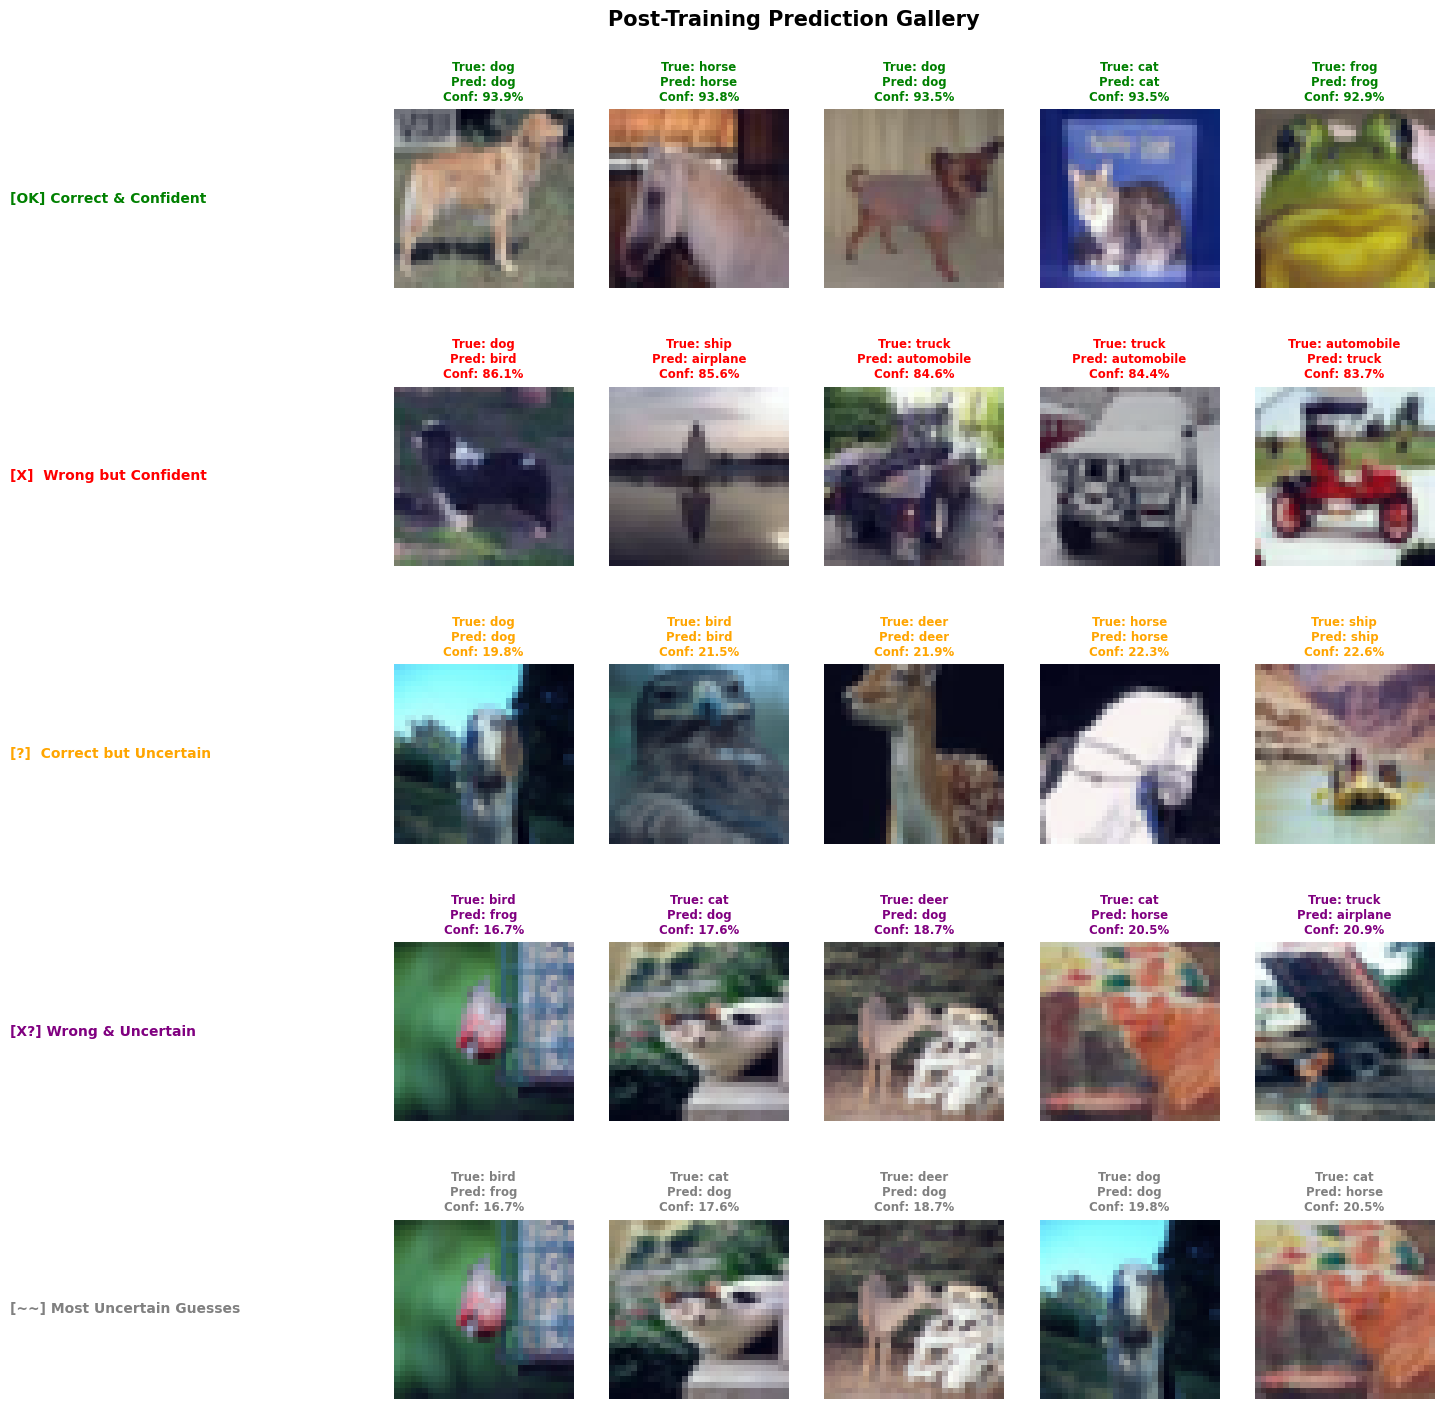

In [12]:
def show_prediction_gallery(net_ema, data_dict, classes, n_each=3, device='cuda'):
    """
    Show three groups of predictions from the test set:
      - Correct & confident   (right answer, high confidence)
      - Wrong & confident     (wrong answer, high confidence — overconfident errors)
      - Correct but uncertain (right answer, low confidence)
    """
    net_ema.net_ema.eval()

    eval_images  = data_dict['eval']['images']
    eval_targets = data_dict['eval']['targets']

    # Support both label formats: class indices [N] or one-hot [N, C].
    if eval_targets.ndim == 2:
        true_labels = eval_targets.argmax(-1).cpu()
    else:
        true_labels = eval_targets.long().cpu()

    # Keep images and labels aligned even if a stale data cache created mismatch.
    if len(true_labels) != len(eval_images):
        n = min(len(true_labels), len(eval_images))
        eval_images = eval_images[:n]
        true_labels = true_labels[:n]

    all_logits = []
    eval_bs = 2500
    with torch.no_grad():
        for i in range(0, len(eval_images), eval_bs):
            batch = eval_images[i:i+eval_bs].to(device)
            logits = net_ema(batch)              # uses TTA (flip averaging) via eval mode
            all_logits.append(logits.cpu().float())

    logits_all = torch.cat(all_logits, dim=0)           # (N, 10)
    probs_all  = torch.softmax(logits_all, dim=-1)      # (N, 10)
    confidence, predicted = probs_all.max(dim=-1)       # top-1 confidence & class

    correct_mask = (predicted == true_labels)

    # 1. Correct & confident
    correct_conf_idx = (correct_mask & (confidence > 0.80)).nonzero(as_tuple=True)[0]
    conf_sorted      = confidence[correct_conf_idx].argsort(descending=True)
    correct_conf_idx = correct_conf_idx[conf_sorted[:n_each]]

    # 2. Wrong & confident
    wrong_conf_idx = (~correct_mask & (confidence > 0.80)).nonzero(as_tuple=True)[0]
    conf_sorted    = confidence[wrong_conf_idx].argsort(descending=True)
    wrong_conf_idx = wrong_conf_idx[conf_sorted[:n_each]]

    # 3. Correct but uncertain
    correct_uncer_idx = (correct_mask & (confidence < 0.50)).nonzero(as_tuple=True)[0]
    conf_sorted       = confidence[correct_uncer_idx].argsort(descending=False)  # least confident first
    correct_uncer_idx = correct_uncer_idx[conf_sorted[:n_each]]

    # 4. Wrong & uncertain
    wrong_uncer_idx = (~correct_mask & (confidence < 0.50)).nonzero(as_tuple=True)[0]
    conf_sorted     = confidence[wrong_uncer_idx].argsort(descending=False)
    wrong_uncer_idx = wrong_uncer_idx[conf_sorted[:n_each]]

    # 5. Most uncertain guesses (lowest confidence overall)
    most_uncer_idx = confidence.argsort(descending=False)[:n_each]

    # Plotting
    groups = [
        (correct_conf_idx,  "[OK] Correct & Confident",    "green"),
        (wrong_conf_idx,    "[X]  Wrong but Confident",     "red"),
        (correct_uncer_idx, "[?]  Correct but Uncertain",   "orange"),
        (wrong_uncer_idx,   "[X?] Wrong & Uncertain",       "purple"),
        (most_uncer_idx,    "[~~] Most Uncertain Guesses",  "gray"),
    ]

    # Un-normalize images for display
    images_cpu = eval_images.cpu().float()
    img_min = images_cpu.min()
    img_max = images_cpu.max()
    images_cpu = (images_cpu - img_min) / (img_max - img_min + 1e-8)

    n_groups = len(groups)
    fig, axes = plt.subplots(n_groups, n_each, figsize=(n_each * 3.2, n_groups * 3.2))
    fig.subplots_adjust(left=0.25, top=0.92, hspace=0.5)
    fig.suptitle("Post-Training Prediction Gallery", fontsize=15, fontweight='bold')

    for row, (indices, group_title, color) in enumerate(groups):
        for col in range(n_each):
            ax = axes[row][col]
            if col < len(indices):
                idx        = indices[col].item()
                img        = images_cpu[idx].permute(1, 2, 0).numpy()
                img        = np.clip(img, 0, 1)
                true_lbl   = classes[true_labels[idx].item()]
                pred_lbl   = classes[predicted[idx].item()]
                conf_val   = confidence[idx].item()

                ax.imshow(img, interpolation='nearest')
                ax.set_title(
                    f"True: {true_lbl}\nPred: {pred_lbl}\nConf: {conf_val:.1%}",
                    fontsize=8.5, color=color, fontweight='bold'
                )
            ax.axis('off')

        bbox     = axes[row][0].get_position()
        y_center = bbox.y0 + bbox.height / 2
        fig.text(0.01, y_center, group_title,
                 fontsize=10, fontweight='bold',
                 color=color, va='center', ha='left')

    plt.show()


# Run only if training produced an EMA model
if 'net_ema' in dir() and net_ema is not None:
    show_prediction_gallery(net_ema, data, CIFAR10_CLASSES,
                            n_each=5, device=hyp['misc']['device'])
else:
    print("No EMA model found — run the training cell first (Section 9).")